# Module 5 — Colors and Colormaps

Color in matplotlib is split into two topics that look similar but work very differently:

```text
┌─────────────────────────────────────────────────────────┐
│ DISCRETE COLORS                                        │
│ "What color is this line / this bar / this group?"     │
│ → named colors, hex codes, color cycles                 │
├─────────────────────────────────────────────────────────┤
│ COLORMAPS                                              │
│ "How do I map a continuous variable to color?"         │
│ → cmap, vmin/vmax, norm, colorbar                       │
└─────────────────────────────────────────────────────────┘
```

For radiology work, the second half matters enormously. Every `imshow()` of a CT slice involves colormap and windowing decisions. The aim is for medical images to look correct, not like generic dashboard output.

## 1. Specifying a single color

Matplotlib accepts colors in many formats.

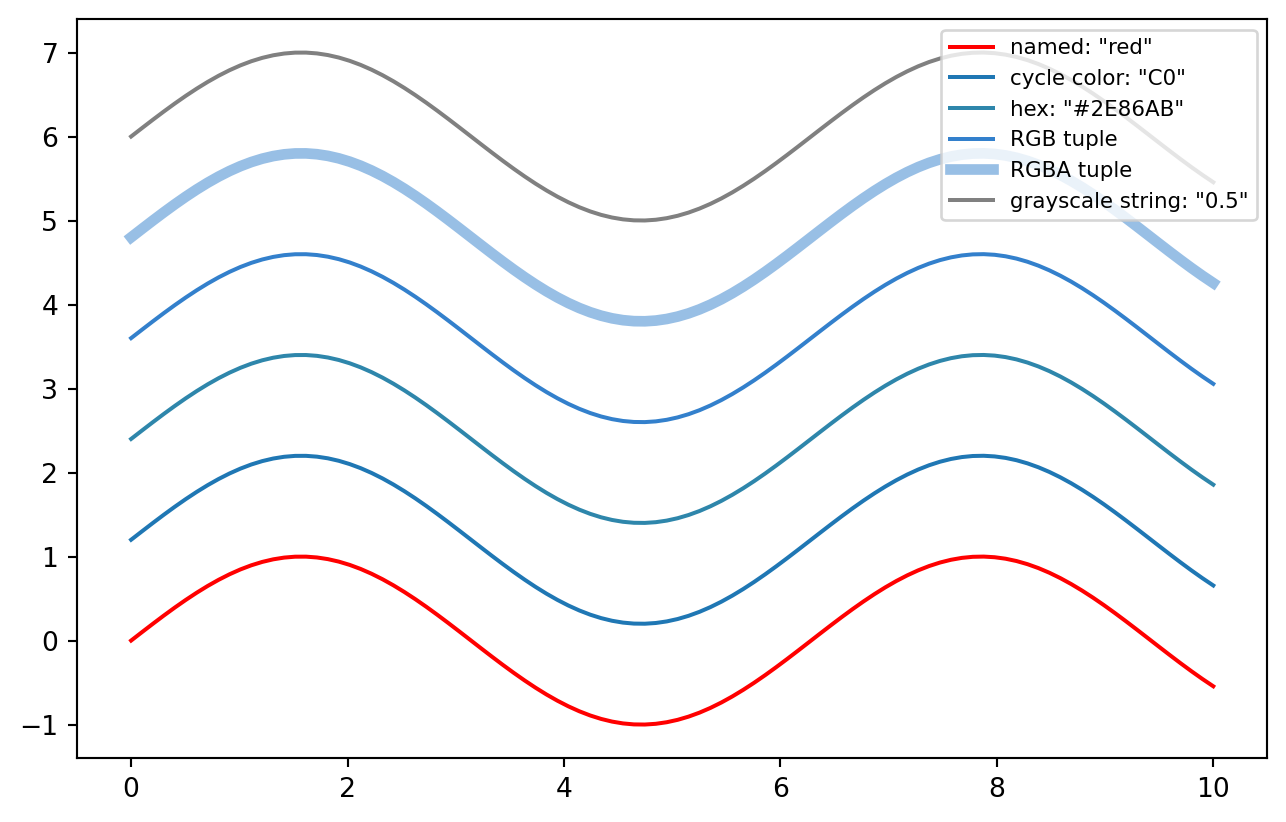

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, y + 0.0, color="red", label='named: "red"')
ax.plot(x, y + 1.2, color="C0", label='cycle color: "C0"')
ax.plot(x, y + 2.4, color="#2E86AB", label='hex: "#2E86AB"')
ax.plot(x, y + 3.6, color=(0.2, 0.5, 0.8), label="RGB tuple")
ax.plot(x, y + 4.8, color=(0.2, 0.5, 0.8, 0.5), linewidth=4, label="RGBA tuple")
ax.plot(x, y + 6.0, color="0.5", label='grayscale string: "0.5"')
ax.legend(loc="upper right", fontsize=8)
plt.show()

Common forms:

```python
ax.plot(x, y, color="red")                 # named color
ax.plot(x, y, color="C0")                  # nth color from the cycle
ax.plot(x, y, color="#2E86AB")             # hex
ax.plot(x, y, color=(0.2, 0.5, 0.8))       # RGB tuple, values 0–1
ax.plot(x, y, color=(0.2, 0.5, 0.8, 0.5))  # RGBA, alpha as fourth value
ax.plot(x, y, color="0.5")                 # grayscale string, 0=black, 1=white
```

Named colors include the basics, such as `"red"` and `"steelblue"`, plus the xkcd survey colors via names like `"xkcd:burnt orange"`.

```text
Color specification — pick one and be consistent
──────────────────────────────────────────────────
Quick exploration:   "red", "steelblue", "C0"
Publication figures: hex codes, e.g. "#2E86AB"
Scientific accuracy: named scheme such as Okabe-Ito
```

## 2. The default color cycle

When multiple lines are drawn without explicit colors, matplotlib cycles through a default palette.

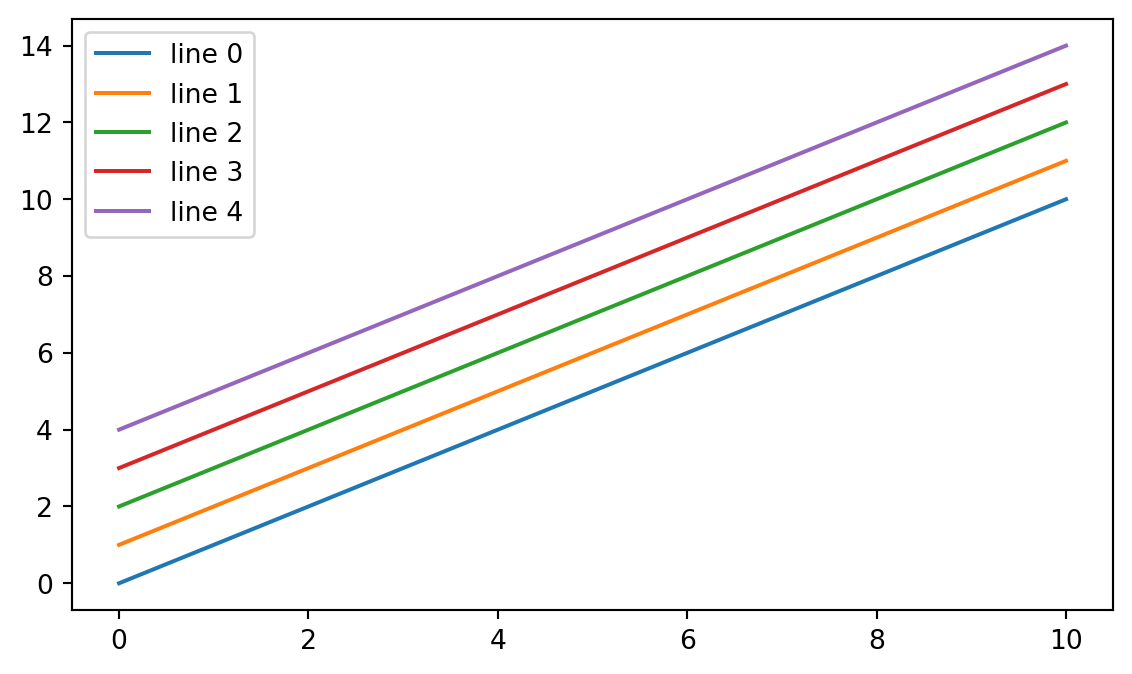

In [2]:
fig, ax = plt.subplots(figsize=(7, 4))
for i in range(5):
    ax.plot(x, x + i, label=f"line {i}")
ax.legend()
plt.show()

The default cycle is based on `tab10`: ten distinguishable colors. You can reference them as `"C0"` through `"C9"`:

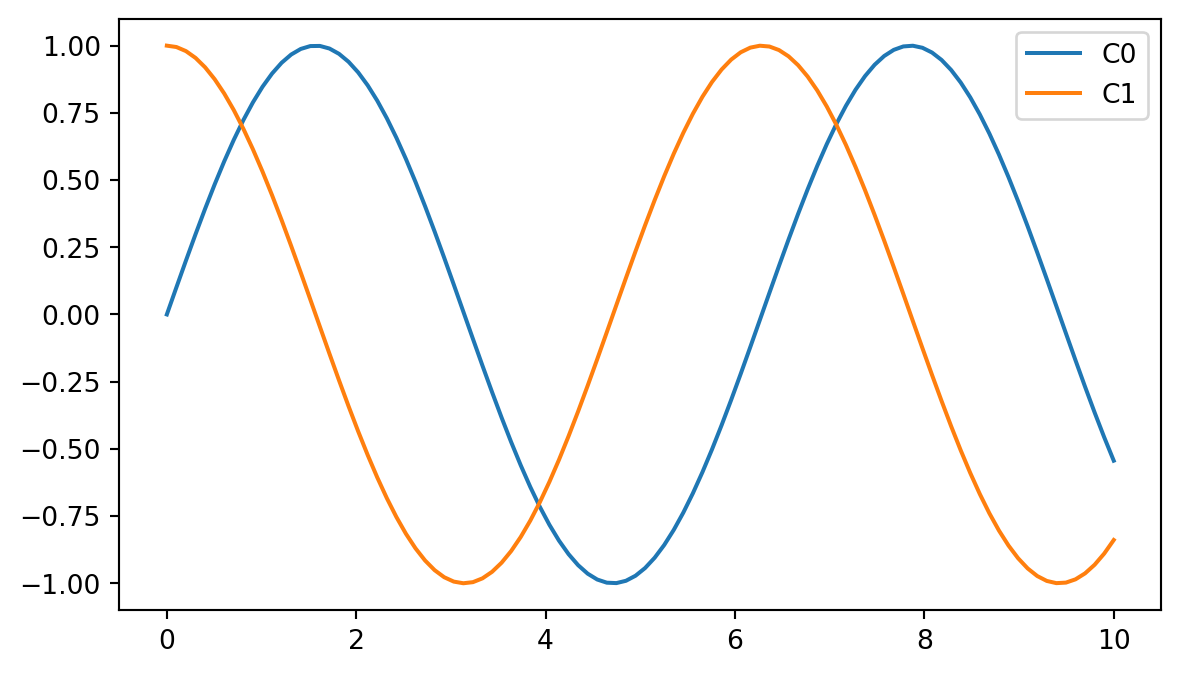

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, np.sin(x), color="C0", label="C0")
ax.plot(x, np.cos(x), color="C1", label="C1")
ax.legend()
plt.show()

This is matplotlib's equivalent of ggplot2's default discrete color scale.

```text
The tab10 default cycle: C0–C9
──────────────────────────────────────────────
C0 blue      C5 brown
C1 orange    C6 pink
C2 green     C7 gray
C3 red       C8 olive
C4 purple    C9 cyan
```

## 3. Changing the color cycle

The default palette can be changed globally through `rcParams`. This is useful when a project should consistently use a specific palette, such as a colorblind-safe one.

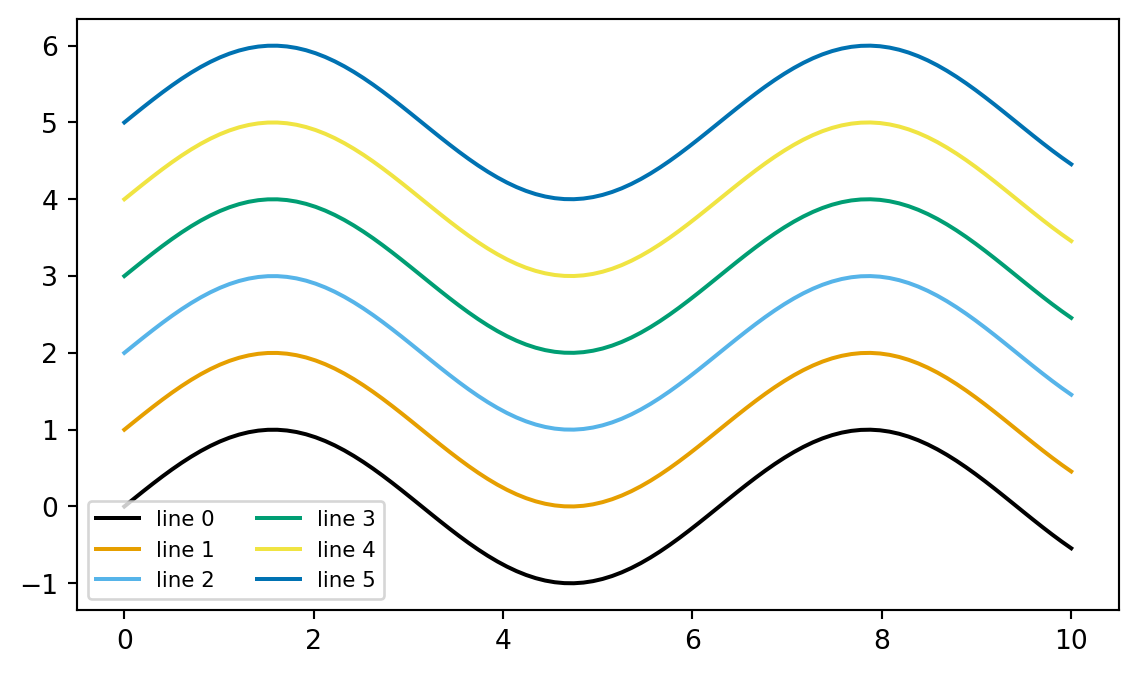

In [4]:
import matplotlib as mpl
from cycler import cycler

okabe_ito = [
    "#000000", "#E69F00", "#56B4E9", "#009E73",
    "#F0E442", "#0072B2", "#D55E00", "#CC79A7",
]

# Use a context so the global setting does not leak into the rest of the notebook.
with mpl.rc_context({"axes.prop_cycle": cycler(color=okabe_ito)}):
    fig, ax = plt.subplots(figsize=(7, 4))
    for i in range(6):
        ax.plot(x, np.sin(x) + i, label=f"line {i}")
    ax.legend(ncol=2, fontsize=8)
    plt.show()

This is roughly equivalent to setting a global ggplot2 theme. Module 7 will cover `rcParams` more systematically.

Useful palettes for grouped or discrete data:

| Palette | Use case | Colorblind-safe? |
|---|---|---|
| `tab10` | General use, ≤10 categories | Mostly |
| `Set1`, `Set2`, `Set3` | Categorical, light/saturated | Mostly |
| Okabe-Ito | Scientific publications | Yes |
| `viridis` | Sequential data, not categories | Yes |

## 4. Colormaps

A colormap maps numbers to colors. When `imshow()` displays a 2D array, matplotlib:

1. normalizes the data into `[0, 1]` based on `vmin`, `vmax`, or `norm`
2. looks up each normalized value in the colormap
3. paints each pixel with the resulting color

```text
Your data       Normalize to [0,1]      Colormap lookup       Pixels
────────        ────────────────        ───────────────       ──────
[-200, 50, 800] → [0.0, 0.25, 1.0]  →   bone(0.0)=black      ▓▓
                                           bone(0.25)=gray    ▒▒
                                           bone(1.0)=white    ░░
```

This means `vmin` and `vmax` are not cosmetic. They determine which numbers map to which colors. For radiology, this is windowing.

### Three families of colormaps

```text
┌──────────────────────────────────────────────────────────┐
│ SEQUENTIAL — data goes from low to high                  │
│ Examples: "viridis", "magma", "Blues", "gray", "bone" │
│ Use for: density, intensity, dose, signal, count          │
│ low ░░░▒▒▒▓▓▓ high                                      │
├──────────────────────────────────────────────────────────┤
│ DIVERGING — data centered on a meaningful midpoint        │
│ Examples: "RdBu", "coolwarm", "seismic", "PiYG"        │
│ Use for: differences, deviations, correlations            │
│ negative ▓▓▓▒▒▒░░░▒▒▒▓▓▓ positive                        │
│                    ↑                                     │
│              zero or neutral midpoint                     │
├──────────────────────────────────────────────────────────┤
│ QUALITATIVE — unordered categories                        │
│ Examples: "tab10", "Set1", "Pastel1"                   │
│ Use for: discrete groups                                  │
│ cat A ▓  cat B ▒  cat C ░                                │
└──────────────────────────────────────────────────────────┘
```

The key rule: match the colormap family to the data structure.

- Sequential maps are for "more is more" data, such as HU values, dose, signal intensity, or counts.
- Diverging maps are for values centered on a meaningful midpoint, such as a residual map or pre/post difference image.
- Qualitative maps are for categories, not continuous measurements.

### Specific colormap recommendations

| Data type | Recommended colormap |
|---|---|
| CT/MRI grayscale display | `"gray"` or `"bone"` |
| PET / fMRI activation overlay | `"hot"` or `"magma"` |
| Probability map from 0 to 1 | `"viridis"` |
| Difference image centered on 0 | `"RdBu_r"` or `"seismic"` |
| Segmentation mask overlay | custom colors + alpha |
| General heatmap of a 2D quantity | `"viridis"` |

The `_r` suffix means reversed. For example, `"RdBu_r"` makes red positive and blue negative, which many readers interpret naturally as hot/cold.

## 5. `vmin`, `vmax`, and `norm`

These are the windowing controls. By default, `imshow()` uses `vmin=data.min()` and `vmax=data.max()`, which is rarely ideal for medical imaging.

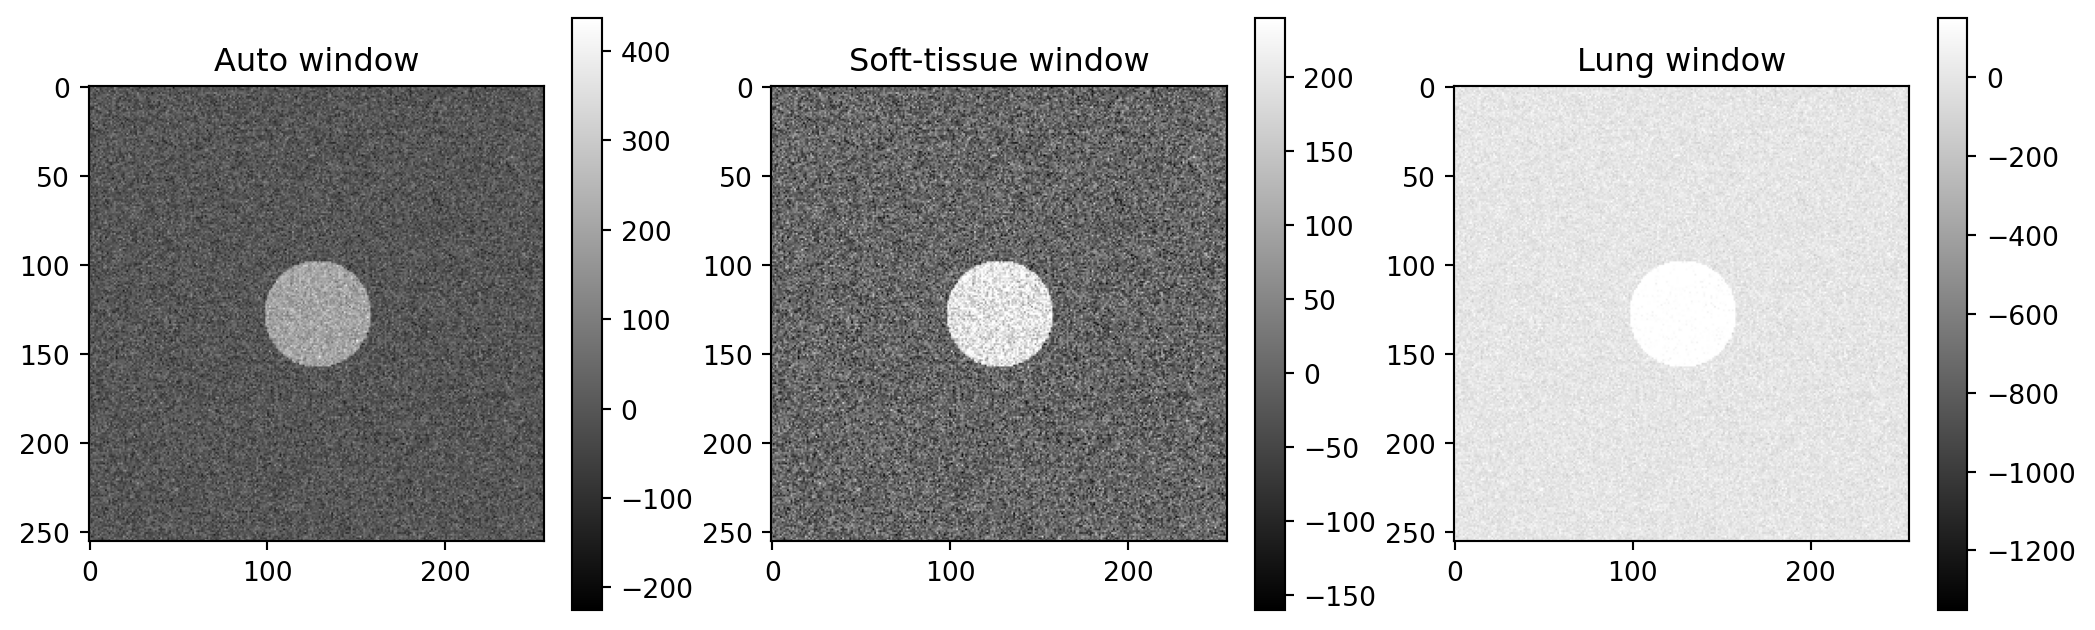

In [5]:
# Simulated CT slice in HU-like values
rng = np.random.default_rng(0)
slice_2d = rng.normal(0, 50, size=(256, 256))
yy, xx = np.ogrid[:256, :256]
slice_2d[(xx - 128) ** 2 + (yy - 128) ** 2 < 30 ** 2] += 200  # soft-tissue mass

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Auto window
im0 = axes[0].imshow(slice_2d, cmap="gray")
axes[0].set_title("Auto window")
fig.colorbar(im0, ax=axes[0])

# Soft-tissue window: W=400, L=40 → vmin=-160, vmax=240
im1 = axes[1].imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
axes[1].set_title("Soft-tissue window")
fig.colorbar(im1, ax=axes[1])

# Lung window: W=1500, L=-600 → vmin=-1350, vmax=150
im2 = axes[2].imshow(slice_2d, cmap="gray", vmin=-1350, vmax=150)
axes[2].set_title("Lung window")
fig.colorbar(im2, ax=axes[2])

plt.show()

Width/level to `vmin`/`vmax` conversion:

```text
vmin = level − width/2
vmax = level + width/2

Soft tissue: W=400,  L=40   → vmin=-160,  vmax=240
Lung:        W=1500, L=-600 → vmin=-1350, vmax=150
Bone:        W=2000, L=300  → vmin=-700,  vmax=1300
Brain:       W=80,   L=40   → vmin=0,     vmax=80
```

This formula is genuinely useful for radiology plotting.

### Beyond `vmin` and `vmax`: `norm`

For nonlinear color mapping, use `norm=`.

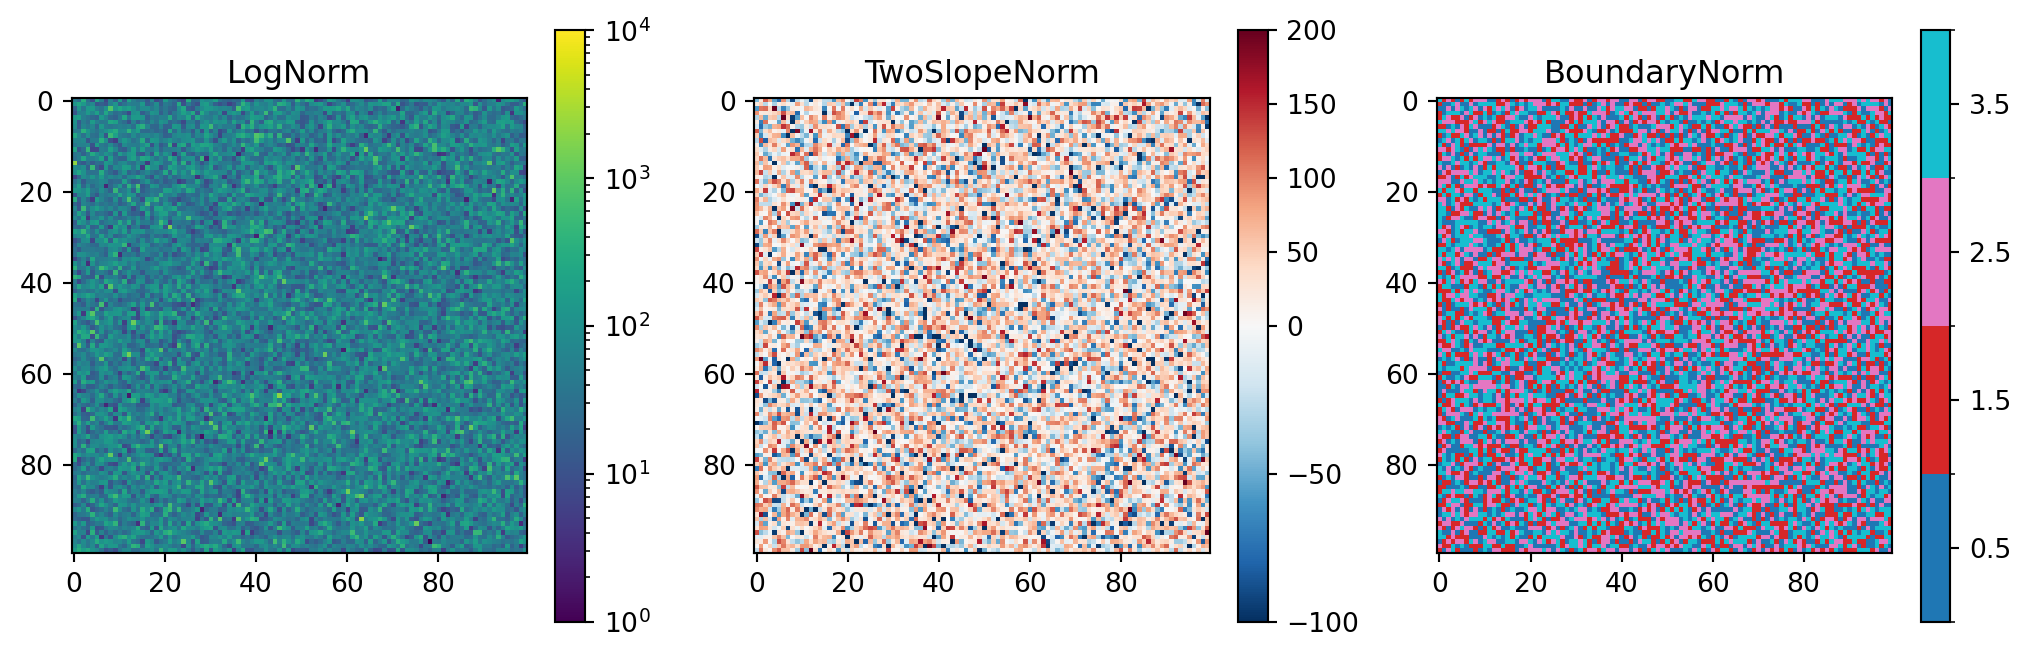

In [6]:
from matplotlib.colors import LogNorm, TwoSlopeNorm, BoundaryNorm

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Logarithmic normalization for data spanning orders of magnitude
data_log = np.exp(rng.normal(4, 1.0, size=(100, 100)))
im0 = axes[0].imshow(data_log, cmap="viridis", norm=LogNorm(vmin=1, vmax=1e4))
axes[0].set_title("LogNorm")
fig.colorbar(im0, ax=axes[0])

# Diverging normalization with zero forced to the center
diff = rng.normal(20, 60, size=(100, 100))
im1 = axes[1].imshow(diff, cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0, vmin=-100, vmax=200))
axes[1].set_title("TwoSlopeNorm")
fig.colorbar(im1, ax=axes[1])

# Boundary normalization for discrete labels/classes
seg = rng.integers(0, 4, size=(100, 100))
im2 = axes[2].imshow(seg, cmap="tab10", norm=BoundaryNorm([0, 1, 2, 3, 4], ncolors=10))
axes[2].set_title("BoundaryNorm")
fig.colorbar(im2, ax=axes[2], ticks=[0.5, 1.5, 2.5, 3.5])

plt.show()

`TwoSlopeNorm(vcenter=0, ...)` is especially useful. It ensures that zero is exactly at the neutral midpoint of a diverging colormap, even when the positive and negative ranges are not symmetric. Without it, zero can shift off-center and the image can mislead the eye.

## 6. Colorbars

The colorbar is the legend for a colormap. The standard pattern is to capture the returned mappable object, then pass it to `fig.colorbar()`.

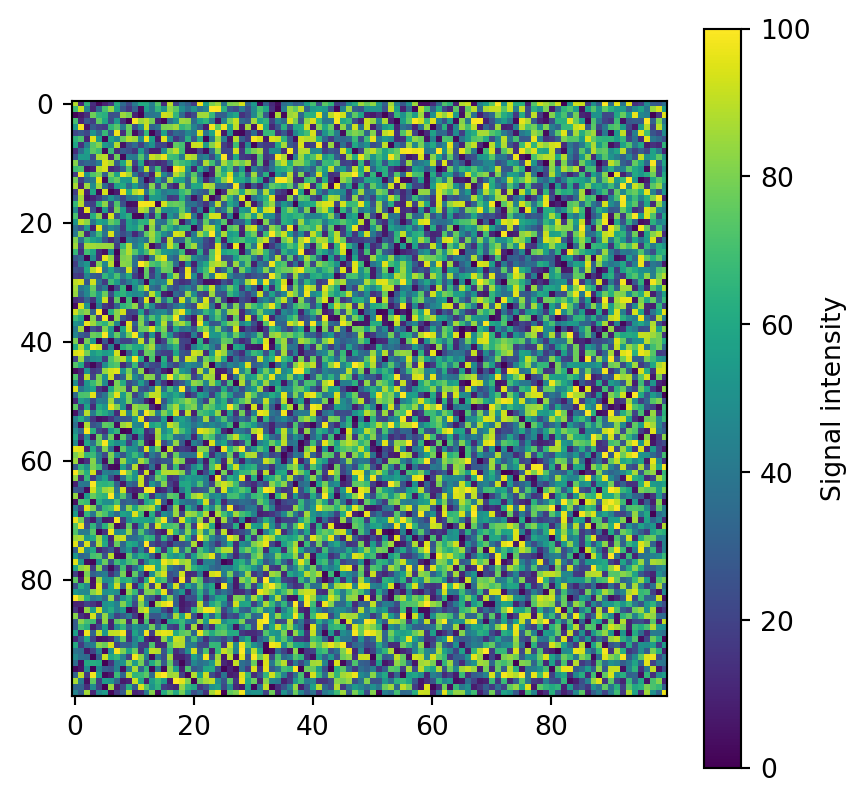

In [7]:
data = rng.uniform(0, 100, size=(100, 100))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(data, cmap="viridis", vmin=0, vmax=100)
fig.colorbar(im, ax=ax, label="Signal intensity")
plt.show()

Two things to remember:

- Drawing calls such as `imshow()`, `scatter()`, `contourf()`, and `pcolormesh()` return a mappable object.
- `fig.colorbar(im, ax=ax)` tells matplotlib which mappable to draw a bar for and which axes to borrow space from.

Useful colorbar customizations:

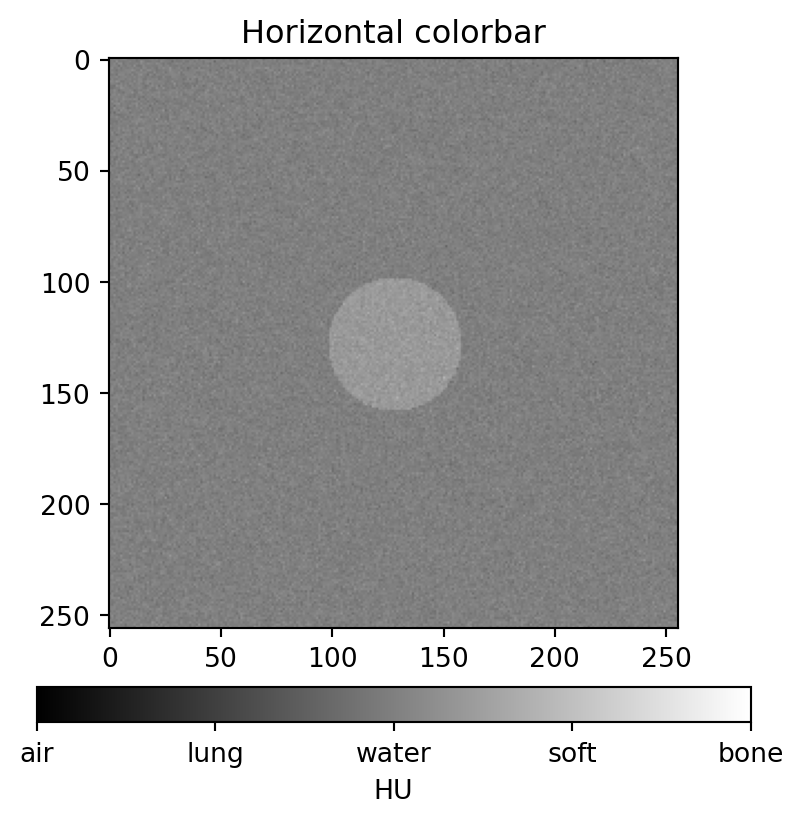

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(slice_2d, cmap="gray", vmin=-1000, vmax=1000)
cbar = fig.colorbar(
    im,
    ax=ax,
    label="HU",
    orientation="horizontal",
    shrink=0.8,
    pad=0.08,
    ticks=[-1000, -500, 0, 500, 1000],
)
cbar.ax.set_xticklabels(["air", "lung", "water", "soft", "bone"])
ax.set_title("Horizontal colorbar")
plt.show()

For multi-panel figures sharing one colorbar, see Module 6.

## 7. Transparency and overlays

`alpha` controls transparency in the range `[0, 1]`. It is the basic mechanism for overlaying one image on another.

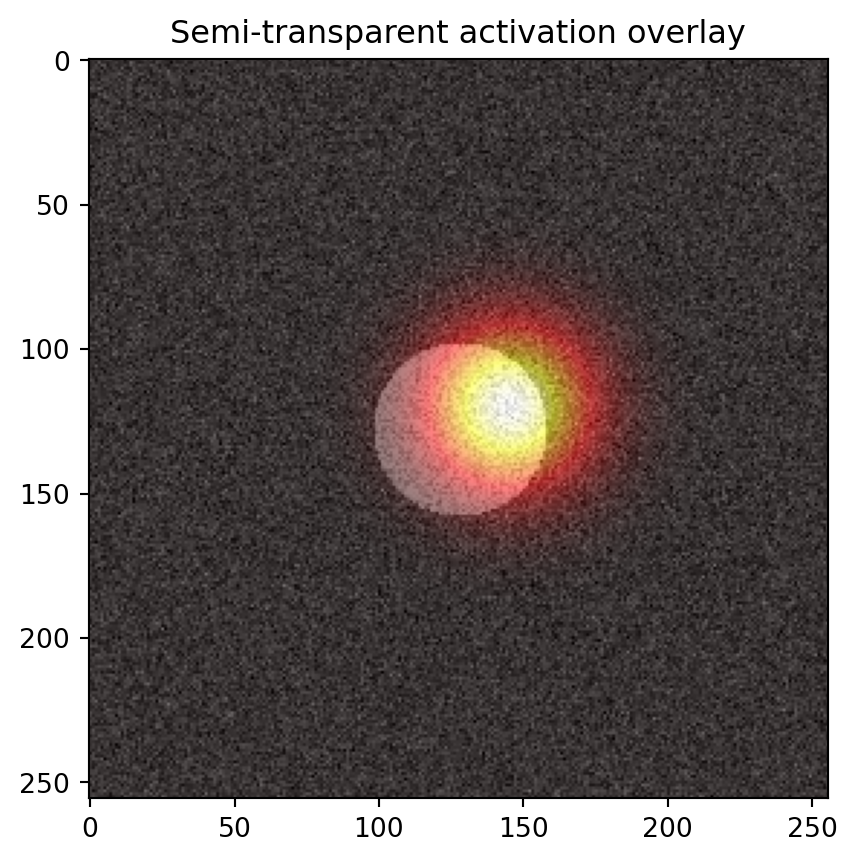

In [9]:
# Simulated activation map on top of the CT-like slice
activation_map = np.exp(-((xx - 145) ** 2 + (yy - 120) ** 2) / (2 * 20 ** 2))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
ax.imshow(activation_map, cmap="hot", alpha=0.5)
ax.set_title("Semi-transparent activation overlay")
plt.show()

An alpha array can have the same shape as the image. This is useful when only certain pixels should show through, such as a segmentation mask.

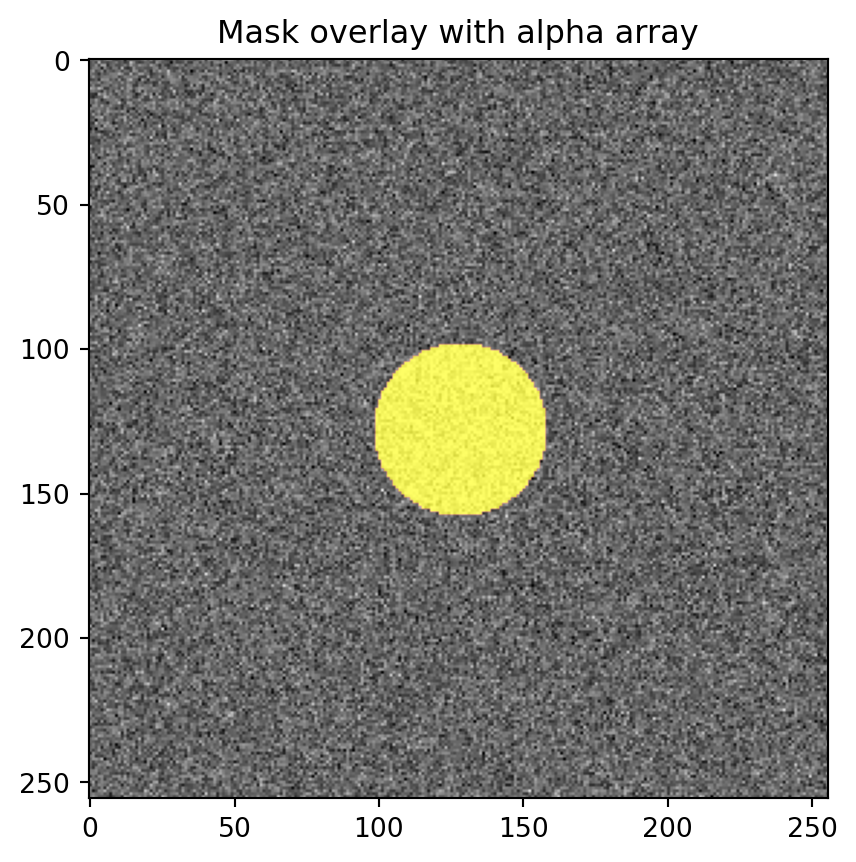

In [10]:
mask = ((xx - 128) ** 2 + (yy - 128) ** 2) < 30 ** 2
overlay_alpha = np.where(mask, 0.6, 0.0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(slice_2d, cmap="gray", vmin=-160, vmax=240)
ax.imshow(mask.astype(float), cmap="autumn", alpha=overlay_alpha)
ax.set_title("Mask overlay with alpha array")
plt.show()

This pattern is the foundation for radiology overlay figures. Module 9 will build the full workflow on top of it.

## 8. Mapping a column to color

For scatter plots where point color encodes a continuous variable, pass the values to `c=` and choose a `cmap`.

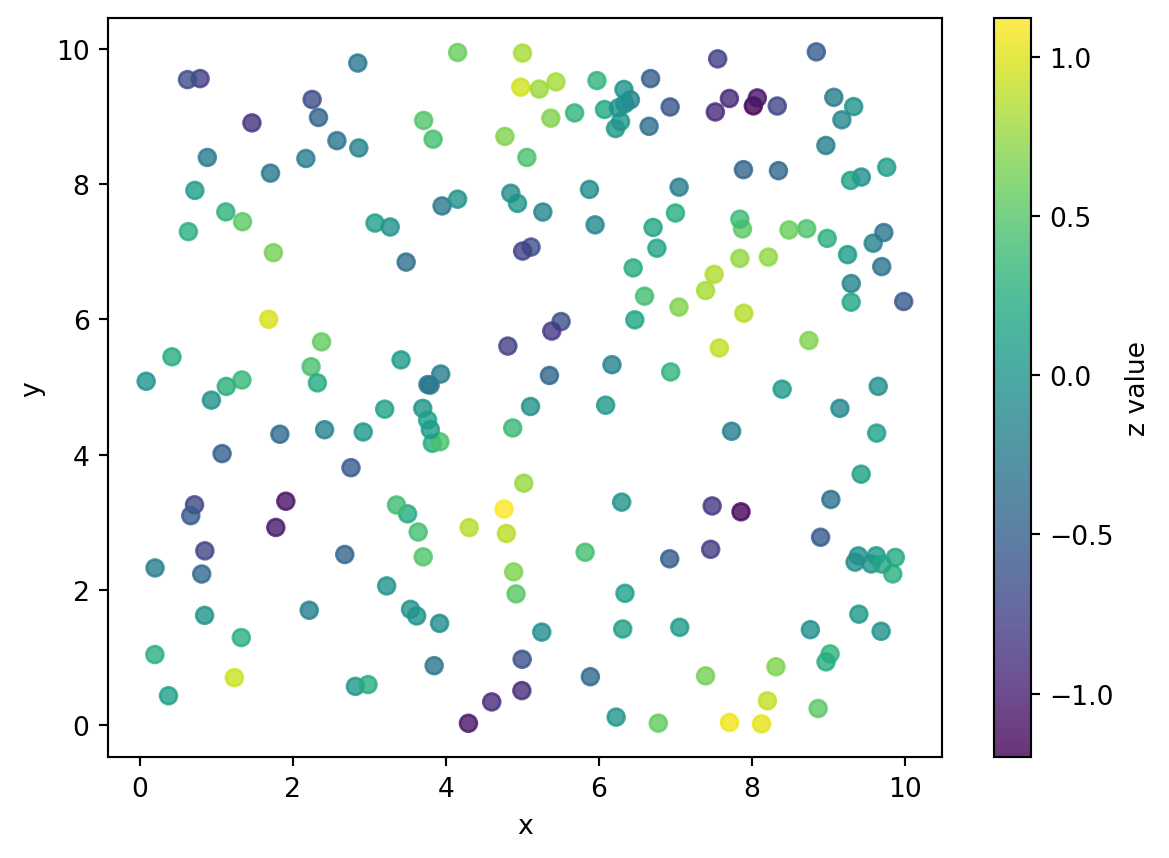

In [11]:
rng = np.random.default_rng(4)
x = rng.uniform(0, 10, 200)
y = rng.uniform(0, 10, 200)
z = np.sin(x) * np.cos(y) + rng.normal(0, 0.1, size=x.size)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(x, y, c=z, cmap="viridis", s=40, alpha=0.8)
fig.colorbar(sc, ax=ax, label="z value")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

This is the matplotlib substitute for `aes(color = z)` with a continuous variable.

For discrete group coloring, loop over groups:

```python
for name, sub in df.groupby("group"):
    ax.scatter(sub["x"], sub["y"], label=name)
```

There is no built-in shortcut exactly like `aes(color = categorical_variable)`. This is one of the strongest reasons to use seaborn for grouped data.

## 9. ggplot2 → matplotlib color cheat sheet

| ggplot2 | matplotlib |
|---|---|
| `scale_color_manual(values = c("red", "blue"))` | loop + `color=` per call |
| `scale_color_brewer(palette = "Set1")` | set `rcParams` color cycle to a similar palette |
| `scale_color_viridis_c()` | `scatter(..., c=z, cmap="viridis")` |
| `scale_fill_gradient(low=, high=)` | `imshow(..., cmap="Blues")` |
| `scale_fill_gradient2(low=, mid=, high=, midpoint=0)` | `imshow(..., cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=0))` |
| `guide_colorbar()` | `fig.colorbar(im, ax=ax)` |

## Exercises

### Exercise 1

Make a line plot with five lines `y = x + i` for `i in range(5)`, but color them using the Okabe-Ito palette from section 3. Use a different color for each line, picked manually.

### Exercise 2

Generate 200 points where `x ~ Uniform(0, 10)`, `y ~ Uniform(0, 10)`, and `z = sin(x) * cos(y) + Normal(0, 0.1)`. Make a scatter plot with `c=z` and a sequential colormap of your choice. Add a colorbar labeled `"z value"`.

### Exercise 3

Build the three-panel windowing example in section 5, but with this twist: instead of three different windows on one slice, simulate a difference image by subtracting two slices. Display it in one panel using `cmap="RdBu_r"` and `TwoSlopeNorm(vcenter=0)`. Make sure zero appears as white or neutral. Add a colorbar.

### Exercise 4

Simulate a 256×256 grayscale slice and a binary mask, such as a circle. Display the slice in `"gray"` with the mask shown as a colored, semi-transparent overlay on top, but only where the mask is 1. Use the alpha-array trick from section 7.

### Exercise 5: conceptual

For each data type, decide which colormap family is appropriate and pick a specific colormap:

- A heatmap of pixel-wise mean absolute error between two AI segmentation models.
- A map of SUV on a PET image.
- A confusion matrix where each cell is the count of cases.
- A pixel-wise change in HU between pre- and post-contrast CT.
- A label map where each integer represents a different organ.

This exercise is where the conceptual distinction between sequential, diverging, and qualitative colormaps matters most.